# Thermal-Aware Job Scheduling with Reinforcement Learning
### Vectorised Training, Curriculum Learning & Pareto Analysis

---

This notebook trains a **MaskablePPO** agent to schedule compute jobs on a simulated server, balancing three competing objectives at once: throughput (complete as many jobs as possible), thermal safety (avoid CPU/GPU overheating), and energy efficiency.

The core idea is simple — real data-centre schedulers almost never think about heat. They use rules like "shortest job first" or "earliest deadline first," and leave thermal management entirely to hardware throttling. That's reactive. We want a scheduler that *anticipates* thermal pressure and adjusts its dispatch decisions proactively.


---



In [4]:
# =================================================================================================
# THERMAL-AWARE RL SCHEDULING
# =================================================================================================

!pip -q install stable-baselines3[extra] sb3-contrib gymnasium scipy


import random
import warnings
import numpy as np
import matplotlib.pyplot as plt

from collections import deque
from dataclasses import dataclass, field
from enum import Enum
from scipy import stats

import gymnasium as gym
from gymnasium import spaces

from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_util import make_vec_env

warnings.filterwarnings("ignore")

# =================================================================================================
# REPRODUCIBILITY
# =================================================================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported.")

Libraries imported.


## 1. Job Definitions

Every job in the system has a type (CPU-bound, GPU-bound, Mixed, Memory-bound), a priority level (Best-Effort, Normal, Latency-Critical), and resource demands. The two most important derived properties are:

- **`slack`** — how much time is left before the deadline is missed  
- **`urgency`** — priority divided by slack; a job becomes more urgent as it runs out of time

These two quantities drive most of the scheduling heuristics used in the baselines, and they're also exposed to the RL agent in the observation vector.

In [5]:
# =================================================================================================
# JOB DEFINITIONS
# =================================================================================================

class JobType(Enum):
    CPU_BOUND    = 0
    GPU_BOUND    = 1
    MIXED        = 2
    MEMORY_BOUND = 3


class Priority(Enum):
    BEST_EFFORT      = 0
    NORMAL           = 1
    LATENCY_CRITICAL = 2


@dataclass
class Job:
    job_id:     int
    job_type:   JobType
    priority:   Priority

    cpu_demand: float
    gpu_demand: float
    mem_demand: float

    duration:   int
    deadline:   int
    arrival:    int

    wait_time:  int = 0

    remaining_time: float = field(init=False)
    assigned_cpu:   bool  = False
    assigned_gpu:   bool  = False
    started:        bool  = False
    completed:      bool  = False

    def __post_init__(self):
        self.remaining_time = float(self.duration)

    @property
    def slack(self):
        return max(0.0, self.deadline - (self.wait_time + self.remaining_time))

    @property
    def urgency(self):
        return (self.priority.value + 1) / max(self.slack, 1.0)


demo = Job(1, JobType.GPU_BOUND, Priority.LATENCY_CRITICAL,
           cpu_demand=0.2, gpu_demand=0.8, mem_demand=2.0,
           duration=6, deadline=18, arrival=0)
print(f"Demo Job | slack={demo.slack:.2f} | urgency={demo.urgency:.3f}")

Demo Job | slack=12.00 | urgency=0.250


## 2. Thermal Model

We simulate chip temperature using a **first-order RC thermal model** — the same kind of lumped-parameter model that shows up in embedded systems and thermal characterisation papers. The differential equation is:

$$\tau \frac{dT}{dt} = P \cdot R_{th} - (T - T_{amb})$$

where $P$ is the instantaneous power draw (watts), $R_{th}$ is the thermal resistance (°C/W), and $C$ is the thermal capacitance. Intuitively: power heats the chip up, and the difference between chip temperature and ambient drives heat away. The larger the capacitance, the slower the chip responds.

The quick demo below runs a CPU and GPU through a 100-step load burst followed by 50 steps of idle, just to make sure the dynamics look physically reasonable before we plug this into the RL environment.

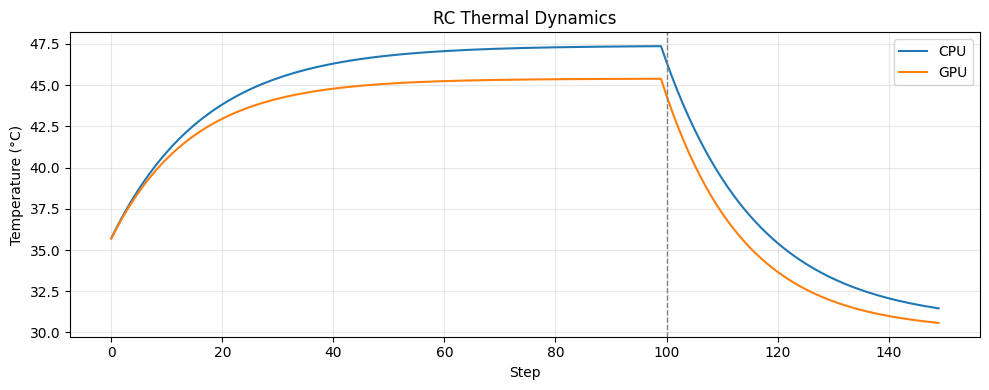

In [6]:
# =================================================================================================
# RC THERMAL MODEL
# =================================================================================================

class RCThermalModel:
    """First-order RC thermal model:  τ·dT/dt = P·R_th − (T − T_amb)"""

    def __init__(self, T_amb: float = 25.0, R_th: float = 0.30, C: float = 55.0):
        self.T_amb = T_amb
        self.R_th  = R_th
        self.C     = C

    def step(self, T: float, P: float) -> float:
        dT = (P - (T - self.T_amb) / self.R_th) / self.C
        return float(np.clip(T + dT, self.T_amb, 120.0))


# ── Quick thermal demo ────────────────────────────────────────────────────────
_cpu_rc = RCThermalModel(T_amb=25.0, R_th=0.28, C=62.0)
_gpu_rc = RCThermalModel(T_amb=25.0, R_th=0.17, C=88.0)
_tc, _tg = 35.0, 35.0
_ct, _gt = [], []

for t in range(150):
    _tc = _cpu_rc.step(_tc, 80 if t < 100 else 20)
    _tg = _gpu_rc.step(_tg, 120 if t < 100 else 30)
    _ct.append(_tc); _gt.append(_tg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(_ct, label="CPU"); ax.plot(_gt, label="GPU")
ax.axvline(100, linestyle="--", color="gray", linewidth=1)
ax.set_title("RC Thermal Dynamics"); ax.set_xlabel("Step"); ax.set_ylabel("Temperature (°C)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. The Scheduling Environment

The environment is built on **Gymnasium** and models a small server with shared CPU, GPU, and memory resources. At each timestep the agent sees a queue of waiting jobs and must decide: which job to schedule next, and on which hardware (CPU only, GPU only, both for mixed-type jobs, or defer it).

**Observation space (51-dim):**  
The first 10 dimensions describe global system state — current resource utilisation, temperatures, total energy, queue depth, and whether either chip is currently throttled. The next 35 dimensions encode the top-5 most urgent jobs (7 features each: type, priority, CPU/GPU/mem demand, remaining time, slack). The last 6 are threshold constants and running-job counts.

**Action space (Discrete 20):**  
5 visible job slots × 4 actions (assign-CPU, assign-GPU, assign-both, defer). Invalid actions (e.g. assigning to a slot when resources are full) are masked out so the agent never has to learn to avoid them — it physically cannot take them.

**Reward structure:**  
- +15 per job completed, plus priority bonus (+1/+3/+8 for BE/Normal/LC)
- +20 if completed before deadline, −2 if missed
- −0.45 × thermal_weight × (T − T_warn) per degree over warning threshold
- −energy_weight × power penalty each step
- Ongoing queue-starvation penalty to discourage parking jobs too long

All rewards are divided by a scale factor of 50 before being returned, so the agent works with values in a reasonable range.

In [7]:
# =================================================================================================
# ENVIRONMENT
# =================================================================================================

class ThermalAwareSchedulingEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(
        self,
        thermal_weight: float = 1.0,
        energy_weight:  float = 1.0,
        lam_base:       float = 1.4,    # [D] configurable arrival rate
        max_steps:      int   = 350,    # [D] configurable episode length
    ):
        super().__init__()

        # ── Hardware ──────────────────────────────────────────────────────────
        self.max_cpu = 2.0
        self.max_gpu = 1.0
        self.max_mem = 12.0

        # ── Thermal thresholds ────────────────────────────────────────────────
        self.cpu_warn_temp      = 55.0
        self.gpu_warn_temp      = 60.0
        self.cpu_throttle_temp  = 65.0
        self.gpu_throttle_temp  = 70.0

        self.cpu_rc = RCThermalModel(T_amb=25.0, R_th=0.42, C=45.0)
        self.gpu_rc = RCThermalModel(T_amb=25.0, R_th=0.30, C=60.0)

        # ── Reward weights ────────────────────────────────────────────────────
        self.thermal_weight = thermal_weight
        self.energy_weight  = energy_weight
        self.reward_scale   = 50.0

        # ── Episode / workload config ─────────────────────────────────────────
        self.max_steps = max_steps
        self.max_queue = 50
        self.lam_base  = lam_base
        self.burst_p   = 0.12
        self.burst_mul = 3

        # ── RL dims ───────────────────────────────────────────────────────────
        self.k_visible_jobs  = 5
        self.actions_per_job = 4

        self.action_space = spaces.Discrete(
            self.k_visible_jobs * self.actions_per_job   # 20
        )

        obs_dim = 10 + (self.k_visible_jobs * 7) + 4 + 2   # 51
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(obs_dim,), dtype=np.float32
        )

        self.reset()

    # =========================================================================
    # RESET
    # =========================================================================

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count     = 0
        self._job_ctr       = 0
        self.queue          = deque()
        self.running_jobs   = []

        self.cpu_util       = 0.0
        self.gpu_util       = 0.0
        self.mem_util       = 0.0

        self.cpu_temp       = 35.0
        self.gpu_temp       = 35.0

        self.total_energy   = 0.0
        self.jobs_completed = 0
        self.sla_violations = 0
        self.thermal_events = 0

        self.cpu_throttled  = False
        self.gpu_throttled  = False

        self.reward_history = []
        return self._obs(), {}

    # =========================================================================
    # WORKLOAD
    # =========================================================================

    def _n_arrivals(self):
        lam = (
            self.lam_base * self.burst_mul
            if np.random.rand() < self.burst_p
            else self.lam_base
        )
        return int(np.random.poisson(lam))

    def _make_job(self):
        self._job_ctr += 1
        jt = int(np.random.choice([0, 1, 2, 3], p=[0.35, 0.35, 0.20, 0.10]))
        pr = int(np.random.choice([0, 1, 2],    p=[0.50, 0.35, 0.15]))

        if   jt == 0: cpu_d, gpu_d = np.random.uniform(0.8, 1.5), np.random.uniform(0.00, 0.15)
        elif jt == 1: cpu_d, gpu_d = np.random.uniform(0.2, 0.5), np.random.uniform(0.70, 1.40)
        elif jt == 2: cpu_d, gpu_d = np.random.uniform(0.7, 1.2), np.random.uniform(0.60, 1.10)
        else:         cpu_d, gpu_d = np.random.uniform(0.3, 0.7), np.random.uniform(0.00, 0.15)

        duration = np.random.randint(6, 18)
        deadline = duration + np.random.randint(5, 20)

        return Job(
            job_id=self._job_ctr, job_type=JobType(jt), priority=Priority(pr),
            cpu_demand=cpu_d, gpu_demand=gpu_d,
            mem_demand=np.random.uniform(0.5, 4.0),
            duration=duration, deadline=deadline, arrival=self.step_count,
        )

    # =========================================================================
    # UTILISATION
    # =========================================================================

    def _recompute_utilization(self):
        cpu = gpu = mem = 0.0
        for j in self.running_jobs:
            if j.assigned_cpu: cpu += j.cpu_demand
            if j.assigned_gpu: gpu += j.gpu_demand
            mem += j.mem_demand
        self.cpu_util = cpu
        self.gpu_util = gpu
        self.mem_util = mem

    # =========================================================================
    # POWER MODEL
    # =========================================================================

    def _power(self):
        P_cpu = 30  + 110 * (self.cpu_util / self.max_cpu) ** 1.6
        P_gpu = 40  + 260 * (self.gpu_util / self.max_gpu) ** 1.5
        return P_cpu, P_gpu

    # =========================================================================
    # OBSERVATION  (51-dim)
    # =========================================================================

    def _obs(self):
        if len(self.queue) <= self.k_visible_jobs:
            visible = list(self.queue)
        else:
            visible = sorted(
                self.queue, key=lambda j: (-j.urgency, -j.priority.value)
            )[:self.k_visible_jobs]

        features = []
        for j in visible:
            features.extend([
                j.job_type.value / 3.0,
                j.priority.value / 2.0,
                j.cpu_demand / self.max_cpu,
                j.gpu_demand / self.max_gpu,
                j.mem_demand / self.max_mem,
                min(j.remaining_time / 18.0, 1.0),
                min(j.slack / 30.0, 1.0),
            ])
        while len(features) < self.k_visible_jobs * 7:
            features.extend([0.0] * 7)

        n_cpu_running = sum(1 for j in self.running_jobs if j.assigned_cpu)
        n_gpu_running = sum(1 for j in self.running_jobs if j.assigned_gpu)

        obs = np.array([
            self.cpu_util / self.max_cpu,
            self.gpu_util / self.max_gpu,
            self.mem_util / self.max_mem,
            self.cpu_temp / 100.0,
            self.gpu_temp / 100.0,
            min(self.total_energy / 1200.0, 1.0),
            len(self.queue) / self.max_queue,
            len(self.running_jobs) / 20.0,
            float(self.cpu_throttled),
            float(self.gpu_throttled),
            *features,
            self.cpu_warn_temp     / 100.0,
            self.gpu_warn_temp     / 100.0,
            self.cpu_throttle_temp / 100.0,
            self.gpu_throttle_temp / 100.0,
            n_cpu_running / 10.0,
            n_gpu_running / 10.0,
        ], dtype=np.float32)

        return np.clip(obs, 0.0, 1.0)

    # =========================================================================
    # THROTTLING
    # =========================================================================

    def _throttle_factor(self):
        cpu_factor = gpu_factor = 1.0

        prev = self.cpu_throttled
        self.cpu_throttled = self.cpu_temp >= self.cpu_throttle_temp
        if self.cpu_throttled and not prev: self.thermal_events += 1
        if self.cpu_throttled: cpu_factor = 0.45

        prev = self.gpu_throttled
        self.gpu_throttled = self.gpu_temp >= self.gpu_throttle_temp
        if self.gpu_throttled and not prev: self.thermal_events += 1
        if self.gpu_throttled: gpu_factor = 0.40

        return cpu_factor, gpu_factor

    # =========================================================================
    # STEP
    # =========================================================================

    def step(self, action):
        self.step_count += 1
        reward = 0.0

        # ── Arrivals ──────────────────────────────────────────────────────────
        for _ in range(self._n_arrivals()):
            if len(self.queue) < self.max_queue:
                self.queue.append(self._make_job())

        # ── Execution ─────────────────────────────────────────────────────────
        cpu_factor, gpu_factor = self._throttle_factor()

        completed_jobs = []
        for j in self.running_jobs:
            speed = 0.0
            if j.assigned_cpu: speed += cpu_factor
            if j.assigned_gpu: speed += gpu_factor
            speed = max(speed, 0.35)
            j.remaining_time -= speed
            if j.remaining_time <= 0:
                completed_jobs.append(j)

        # ── Completions ───────────────────────────────────────────────────────
        for j in completed_jobs:
            j.completed = True
            self.running_jobs.remove(j)
            self.jobs_completed += 1

            reward += 15.0
            reward += [1.0, 3.0, 8.0][j.priority.value]

            if (self.step_count - j.arrival) <= j.deadline:
                reward += 20.0
            else:
                self.sla_violations += 1
                reward -= 2.0

        self._recompute_utilization()

        # ── Thermal ───────────────────────────────────────────────────────────
        P_cpu, P_gpu = self._power()
        self.cpu_temp = self.cpu_rc.step(self.cpu_temp, P_cpu)
        self.gpu_temp = self.gpu_rc.step(self.gpu_temp, P_gpu)

        step_energy = (P_cpu + P_gpu) * 1e-3
        self.total_energy += step_energy

        # ── Queue starvation ──────────────────────────────────────────────────
        expired = []
        for j in self.queue:
            j.wait_time += 1
            reward -= 0.004 * (1 + j.priority.value)
            if (self.step_count - j.arrival) > j.deadline:
                expired.append(j)
                self.sla_violations += 1
                reward -= 3.0 * (1 + j.priority.value)
        for j in expired:
            try: self.queue.remove(j)
            except ValueError: pass

        # ── Action decode ─────────────────────────────────────────────────────
        if self.queue:
            visible = sorted(
                self.queue, key=lambda j: (-j.urgency, -j.priority.value)
            )[:self.k_visible_jobs]

            job_idx   = action // self.actions_per_job
            hw_action = action  % self.actions_per_job

            if job_idx >= len(visible):
                reward -= 2.0
            else:
                job    = visible[job_idx]
                cpu_ok = self.cpu_util + job.cpu_demand <= self.max_cpu
                gpu_ok = self.gpu_util + job.gpu_demand <= self.max_gpu
                mem_ok = self.mem_util + job.mem_demand <= self.max_mem

                success = False

                if hw_action == 0 and cpu_ok and mem_ok:
                    job.assigned_cpu, job.assigned_gpu = True, False; success = True

                elif hw_action == 1 and gpu_ok and mem_ok:
                    job.assigned_cpu, job.assigned_gpu = False, True; success = True

                elif (hw_action == 2 and cpu_ok and gpu_ok and mem_ok
                      and job.job_type == JobType.MIXED):
                    job.assigned_cpu, job.assigned_gpu = True, True; success = True

                elif hw_action == 3:
                    reward -= 0.25

                if success:
                    self.queue.remove(job)
                    job.started = True
                    self.running_jobs.append(job)
                    self._recompute_utilization()

                    reward += 5.0
                    reward += {
                        (JobType.CPU_BOUND,    0): 4.0,
                        (JobType.GPU_BOUND,    1): 4.0,
                        (JobType.MIXED,        2): 5.5,
                        (JobType.MEMORY_BOUND, 0): 2.0,
                    }.get((job.job_type, hw_action), -2.0)

                elif hw_action != 3:
                    reward -= 3.0

        # ── Thermal penalty ───────────────────────────────────────────────────
        for T, warn in [(self.cpu_temp, self.cpu_warn_temp),
                         (self.gpu_temp, self.gpu_warn_temp)]:
            if T > warn:
                reward -= self.thermal_weight * 0.45 * (T - warn)

        reward -= self.energy_weight * step_energy * 0.008
        reward -= 0.002 * len(self.queue)

        done = self.step_count >= self.max_steps
        scaled = reward / self.reward_scale
        self.reward_history.append(scaled)
        return self._obs(), scaled, done, False, {}


# ── Sanity check ──────────────────────────────────────────────────────────────
_env_test = ThermalAwareSchedulingEnv()
_obs, _   = _env_test.reset()
print(f"Obs shape: {_obs.shape}  |  Action space: {_env_test.action_space}")

Obs shape: (51,)  |  Action space: Discrete(20)


## 4. Action Masking

One of the biggest practical problems in discrete-action RL for scheduling is the **invalid-action problem**: an agent can waste thousands of training steps learning that it can't assign a GPU job when the GPU is already full. Action masking solves this at the source — before the policy even samples, we build a boolean mask of currently-valid actions and pass it to `MaskablePPO`, which zeroes out invalid action logits before computing the softmax.

The masking logic is straightforward: for each of the 5 visible job slots, we check whether the job's resource demands fit within remaining capacity, and enable only the hardware options that are feasible. The DEFER action is always valid.

In [8]:
# =================================================================================================
# ACTION MASKING
# =================================================================================================

def make_mask(env: ThermalAwareSchedulingEnv) -> np.ndarray:
    """Boolean validity mask over all 20 actions."""
    n    = env.action_space.n
    mask = np.zeros(n, dtype=bool)

    if not env.queue:
        mask[3] = True   # only DEFER on slot 0
        return mask

    visible = sorted(
        env.queue, key=lambda j: (-j.urgency, -j.priority.value)
    )[:env.k_visible_jobs]

    for i, job in enumerate(visible):
        cpu_ok = env.cpu_util + job.cpu_demand <= env.max_cpu
        gpu_ok = env.gpu_util + job.gpu_demand <= env.max_gpu
        mem_ok = env.mem_util + job.mem_demand <= env.max_mem
        base   = i * env.actions_per_job

        if cpu_ok and mem_ok:                                               mask[base + 0] = True
        if gpu_ok and mem_ok:                                               mask[base + 1] = True
        if cpu_ok and gpu_ok and mem_ok and job.job_type == JobType.MIXED: mask[base + 2] = True
        mask[base + 3] = True  # DEFER always valid

    return mask


def _mask_fn(env):
    """Adapter for ActionMasker wrapper."""
    return make_mask(env)

# =================================================================================================
# HELPERS
# =================================================================================================

def encode_action(job_idx: int, hw: int) -> int:
    return job_idx * 4 + hw


def best_action(job: Job, env: ThermalAwareSchedulingEnv) -> int:
    cpu_ok = env.cpu_util + job.cpu_demand <= env.max_cpu
    gpu_ok = env.gpu_util + job.gpu_demand <= env.max_gpu
    mem_ok = env.mem_util + job.mem_demand <= env.max_mem

    if not mem_ok: return 3

    if job.job_type == JobType.CPU_BOUND:    return 0 if cpu_ok else 3
    if job.job_type == JobType.GPU_BOUND:    return 1 if gpu_ok else 3
    if job.job_type == JobType.MIXED:
        if cpu_ok and gpu_ok: return 2
        if gpu_ok:            return 1
        if cpu_ok:            return 0
        return 3
    if job.job_type == JobType.MEMORY_BOUND: return 0 if cpu_ok else 3
    return 3

## 5. Baseline Schedulers

Before we train anything, we need something to compare against. Five classic schedulers are implemented as simple heuristics:

- **FCFS** — First Come First Served. Serves the job that arrived earliest. No intelligence at all, just a queue.
- **SJF** — Shortest Job First. Picks the job with the smallest expected duration. Optimal for minimising average wait time in ideal conditions, but blind to deadlines.
- **Priority** — Always serves the highest-priority job first. Good for latency-critical jobs, but can starve everything else.
- **EDF** — Earliest Deadline First. Picks the job whose deadline is coming up soonest. Theoretically optimal for meeting deadlines on a uniprocessor, but still ignores temperature.
- **ThermalSafe** — A hand-crafted rule: pick the most urgent job, but refuse to schedule it if a relevant chip is already hot. Essentially EDF with a thermal veto.

None of these baselines learn — they're fixed rules. The RL agent needs to beat all of them on cumulative reward to justify the training cost.

In [9]:
# =================================================================================================
# BASELINES
# =================================================================================================

class FCFSScheduler:
    name = "FCFS"
    def act(self, env):
        if not env.queue: return encode_action(0, 3)
        return encode_action(0, best_action(sorted(env.queue, key=lambda j: j.arrival)[0], env))


class SJFScheduler:
    name = "SJF"
    def act(self, env):
        if not env.queue: return encode_action(0, 3)
        return encode_action(0, best_action(sorted(env.queue, key=lambda j: j.duration)[0], env))


class PriorityScheduler:
    name = "Priority"
    def act(self, env):
        if not env.queue: return encode_action(0, 3)
        return encode_action(0, best_action(sorted(env.queue, key=lambda j: -j.priority.value)[0], env))


class EDFScheduler:
    name = "EDF"
    def act(self, env):
        if not env.queue: return encode_action(0, 3)
        return encode_action(0, best_action(sorted(env.queue, key=lambda j: j.arrival + j.deadline)[0], env))


class ThermalSafeScheduler:
    name = "ThermalSafe"
    def act(self, env):
        if not env.queue: return encode_action(0, 3)
        job = sorted(env.queue, key=lambda j: -j.urgency)[0]
        if env.cpu_temp > env.cpu_warn_temp + 5 and job.job_type == JobType.CPU_BOUND: return encode_action(0, 3)
        if env.gpu_temp > env.gpu_warn_temp + 5 and job.job_type == JobType.GPU_BOUND: return encode_action(0, 3)
        return encode_action(0, best_action(job, env))


BASELINES = [FCFSScheduler(), SJFScheduler(), PriorityScheduler(), EDFScheduler(), ThermalSafeScheduler()]
print("Baselines:", [b.name for b in BASELINES])

Baselines: ['FCFS', 'SJF', 'Priority', 'EDF', 'ThermalSafe']


## 6. Training — Vectorised & Curriculum

### 6a. Callback

The `EpisodeLogger` callback collects completed-episode rewards from all parallel environments and averages them every `log_freq` episodes. This gives us the training curve we'll plot later.

### 6b. Vectorised environments [A]

We run `N_ENVS = 4` environments in parallel using `make_vec_env`. Each environment generates independent episode rollouts simultaneously — the PPO update then pools all 4 × 2048 = 8192 steps per batch. This alone cuts wall-clock training time by roughly 4×.

### 6c. Curriculum training [B]

A two-phase curriculum:

**Phase 1 (150 k steps, thermal_weight = 0.3):** The thermal penalty is intentionally weak. The agent focuses on learning *what* to schedule and *when* — building up the core dispatching skill of matching job types to hardware efficiently.

**Phase 2 (150 k steps, thermal_weight = 1.0):** We swap the environment for one with full thermal penalty and continue training without resetting the step counter. Now the agent refines its policy to actively avoid thermal violations on top of the efficient dispatching it already knows. Training the full penalty from scratch risks the agent getting stuck in conservative local optima that keep temperatures low but sacrifice throughput.

### 6d. Pareto sweep [C]

We also train 5 agents with fixed (thermal_weight, energy_weight) configurations: (0.5,0.5), (1.0,0.5), (0.5,1.0), (1.0,1.0), (2.0,1.0). Plotting their evaluation outcomes on a Pareto front shows how the weights trade off throughput against thermal safety and energy.

In [10]:
# =================================================================================================
# CALLBACK
# =================================================================================================

class EpisodeLogger(BaseCallback):

    def __init__(self, log_freq: int = 5):
        super().__init__(verbose=0)
        self.log_freq   = log_freq
        self.ep_rewards = []
        self._buf       = []

    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self._buf.append(info["episode"]["r"])
                if len(self._buf) >= self.log_freq:
                    self.ep_rewards.append(np.mean(self._buf))
                    self._buf = []
        return True

# =================================================================================================
# ENV FACTORY  [A] vectorised
# =================================================================================================

N_ENVS = 4   # parallel environments

def make_env_fn(
    thermal_weight: float = 1.0,
    energy_weight:  float = 1.0,
    lam_base:       float = 1.4,
    max_steps:      int   = 350,
):
    """Returns a callable that creates one masked + monitored env instance."""
    def _make():
        raw = ThermalAwareSchedulingEnv(
            thermal_weight=thermal_weight,
            energy_weight=energy_weight,
            lam_base=lam_base,
            max_steps=max_steps,
        )
        masked = ActionMasker(raw, _mask_fn)
        return Monitor(masked)
    return _make

# =================================================================================================
# TRAINING  [A]+[B]+[C]
# =================================================================================================

PPO_KWARGS = dict(
    learning_rate = 3e-4,
    n_steps       = 2048,
    batch_size    = 256,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.01,
    policy_kwargs = dict(net_arch=[256, 256, 128]),
    verbose       = 0,
    seed          = SEED,
)


def train_curriculum(
    phase1_steps:   int   = 150_000,
    phase2_steps:   int   = 150_000,
    energy_weight:  float = 1.0,
    lam_base:       float = 1.4,
    max_steps:      int   = 350,
) -> tuple:
    """
    [B] Two-phase curriculum:
        Phase 1  thermal_weight=0.3  → agent learns to pack jobs fast
        Phase 2  thermal_weight=1.0  → agent refines thermal awareness
    Returns (model, combined_curve).
    """
    print("── Curriculum Phase 1  (thermal_weight=0.3) ──")
    env1 = make_vec_env(
        make_env_fn(0.3, energy_weight, lam_base, max_steps),
        n_envs=N_ENVS
    )
    cb1   = EpisodeLogger(log_freq=5)
    model = MaskablePPO("MlpPolicy", env1, **PPO_KWARGS)
    model.learn(total_timesteps=phase1_steps, callback=cb1)

    print("── Curriculum Phase 2  (thermal_weight=1.0) ──")
    env2 = make_vec_env(
        make_env_fn(1.0, energy_weight, lam_base, max_steps),
        n_envs=N_ENVS
    )
    cb2 = EpisodeLogger(log_freq=5)
    model.set_env(env2)
    model.learn(
        total_timesteps=phase2_steps,
        callback=cb2,
        reset_num_timesteps=False,   # continue global step counter
    )

    curve = cb1.ep_rewards + cb2.ep_rewards
    phase1_len = len(cb1.ep_rewards)
    return model, curve, phase1_len


def train_single(
    thermal_weight: float = 1.0,
    energy_weight:  float = 1.0,
    timesteps:      int   = 150_000,
    lam_base:       float = 1.4,
    max_steps:      int   = 350,
    seed:           int   = SEED,
) -> MaskablePPO:
    """Train one agent with fixed weights (used by Pareto sweep)."""
    env = make_vec_env(
        make_env_fn(thermal_weight, energy_weight, lam_base, max_steps),
        n_envs=N_ENVS
    )
    model = MaskablePPO("MlpPolicy", env, seed=seed, **{k: v for k, v in PPO_KWARGS.items() if k != "seed"})
    model.learn(total_timesteps=timesteps)
    return model


# ── Main curriculum model ─────────────────────────────────────────────────────
print("=" * 70)
model_main, curve_main, phase1_cut = train_curriculum(
    phase1_steps=150_000,
    phase2_steps=150_000,
)
print("Curriculum training complete.")

# =================================================================================================
# PARETO SWEEP  [C]
# =================================================================================================

PARETO_CONFIGS = [
    (0.5, 0.5),
    (1.0, 0.5),
    (0.5, 1.0),
    (1.0, 1.0),
    (2.0, 1.0),
]

print("\n── Pareto sweep ──")
pareto_models = {}
for tw, ew in PARETO_CONFIGS:
    label = f"tw={tw}_ew={ew}"
    print(f"   Training {label}  …")
    pareto_models[label] = train_single(
        thermal_weight=tw,
        energy_weight=ew,
        timesteps=100_000,
    )

print("Pareto sweep complete.")

── Curriculum Phase 1  (thermal_weight=0.3) ──
── Curriculum Phase 2  (thermal_weight=1.0) ──
Curriculum training complete.

── Pareto sweep ──
   Training tw=0.5_ew=0.5  …
   Training tw=1.0_ew=0.5  …
   Training tw=0.5_ew=1.0  …
   Training tw=1.0_ew=1.0  …
   Training tw=2.0_ew=1.0  …
Pareto sweep complete.


## 7. Evaluation

Each policy is evaluated over **N=100 independent episodes** — enough to get stable mean-and-std estimates without taking forever. For each episode we record:

| Metric | What it measures |
|---|---|
| `reward` | Total scaled reward — the RL objective |
| `completed` | Number of jobs that finished |
| `sla_viol` | Jobs that missed their deadline |
| `thermal_ev` | Times a chip entered throttle territory |
| `energy` | Total energy consumed in kJ |
| `cpu_temp` | Final CPU temperature at episode end |
| `gpu_temp` | Final GPU temperature at episode end |

We report mean ± std across episodes. We also run **Welch's t-tests** (unequal variance) comparing Thermal-PPO against each baseline on raw reward samples, flagging results at the p < 0.05 significance level.

In [11]:
# =================================================================================================
# EVALUATION HELPERS
# =================================================================================================

N_EVAL = 100


def _run_episode(env: ThermalAwareSchedulingEnv, policy_fn) -> dict:
    obs, _ = env.reset()
    done   = False
    total  = 0.0
    while not done:
        a = policy_fn(obs, env)
        obs, r, done, _, _ = env.step(a)
        total += r
    return dict(
        reward=total,
        completed=env.jobs_completed,
        sla_viol=env.sla_violations,
        thermal_ev=env.thermal_events,
        energy=env.total_energy,
        cpu_temp=env.cpu_temp,
        gpu_temp=env.gpu_temp,
    )


def evaluate(
    policy_fn,
    n:         int   = N_EVAL,
    lam_base:  float = 1.4,
    max_steps: int   = 350,
) -> dict:
    keys    = ["reward", "completed", "sla_viol", "thermal_ev", "energy", "cpu_temp", "gpu_temp"]
    buckets = {k: [] for k in keys}
    for _ in range(n):
        env = ThermalAwareSchedulingEnv(lam_base=lam_base, max_steps=max_steps)
        row = _run_episode(env, policy_fn)
        for k in keys: buckets[k].append(row[k])
    return {k: (np.mean(v), np.std(v)) for k, v in buckets.items()}


def rl_fn(model: MaskablePPO):
    """Inference policy with action masking."""
    def policy(obs, env):
        mask   = make_mask(env)
        action, _ = model.predict(obs, action_masks=mask, deterministic=True)
        return int(action)
    return policy


def raw_rewards(policy_fn, n=N_EVAL, lam_base=1.4, max_steps=350) -> list:
    out = []
    for _ in range(n):
        env  = ThermalAwareSchedulingEnv(lam_base=lam_base, max_steps=max_steps)
        obs, _ = env.reset()
        done = False; total = 0.0
        while not done:
            a = policy_fn(obs, env)
            obs, r, done, _, _ = env.step(a)
            total += r
        out.append(total)
    return out

# =================================================================================================
# STANDARD EVALUATION  (same workload as training: lam=1.4, steps=350)
# =================================================================================================

print("\n── Standard evaluation ──")
results = {}

for s in BASELINES:
    print(f"   {s.name}…")
    results[s.name] = evaluate(lambda obs, env, sc=s: sc.act(env))

print("   Thermal-PPO (curriculum)…")
results["Thermal-PPO"] = evaluate(rl_fn(model_main))

# ── Results table ─────────────────────────────────────────────────────────────
COLS = ["reward", "completed", "sla_viol", "thermal_ev", "energy", "cpu_temp", "gpu_temp"]
hdr  = f"{'Scheduler':<18}" + "".join(f"{c:>18}" for c in COLS)

print("\n" + "=" * len(hdr))
print(f"STANDARD EVALUATION  (lam=1.4, steps=350, N={N_EVAL})")
print("=" * len(hdr))
print(hdr)
print("-" * len(hdr))
for name, m in results.items():
    print(f"{name:<18}" + "".join(f"{m[c][0]:>11.2f}±{m[c][1]:<5.1f}" for c in COLS))
print("=" * len(hdr))

# ── Welch's t-test ────────────────────────────────────────────────────────────
print("\nCollecting samples for t-tests…")
raw = {"Thermal-PPO": raw_rewards(rl_fn(model_main))}
for s in BASELINES:
    raw[s.name] = raw_rewards(lambda obs, env, sc=s: sc.act(env))

print(f"\nWelch's t-test  (Thermal-PPO vs baseline)")
print(f"{'Baseline':<18} {'t-stat':>10} {'p-value':>10} {'result':>22}")
print("─" * 66)
for name, vals in raw.items():
    if name == "Thermal-PPO": continue
    t, p    = stats.ttest_ind(raw["Thermal-PPO"], vals, equal_var=False)
    better  = np.mean(raw["Thermal-PPO"]) > np.mean(vals)
    sig     = ("PPO better ***" if p < 0.05 and better else
               "Baseline better ***" if p < 0.05 else "no significant diff")
    print(f"{name:<18} {t:>10.3f} {p:>10.4f} {sig:>22}")


── Standard evaluation ──
   FCFS…
   SJF…
   Priority…
   EDF…
   ThermalSafe…
   Thermal-PPO (curriculum)…

STANDARD EVALUATION  (lam=1.4, steps=350, N=100)
Scheduler                     reward         completed          sla_viol        thermal_ev            energy          cpu_temp          gpu_temp
------------------------------------------------------------------------------------------------------------------------------------------------
FCFS                   -41.92±13.3       50.04±5.4       526.20±18.4        3.25±1.8        59.73±8.3        54.49±4.9        56.41±16.6 
SJF                    -38.97±9.7        42.97±5.8       528.80±19.8        2.08±1.5        50.64±7.8        51.76±6.6        49.21±14.2 
Priority               -65.95±16.2       38.22±4.1       530.34±18.0        4.65±1.8        71.81±9.0        53.63±6.9        66.36±19.2 
EDF                    -39.58±15.7       63.57±4.9       526.78±19.5        4.31±1.8        67.96±8.2        56.87±4.5        62.69±17.4

## 8. Stress Test — Harder Workload [D]

Standard evaluation uses `lam=1.4` arrivals/step and 350-step episodes. Here we push the system hard: `lam=2.0` (43% higher arrival rate) and 500-step episodes. This tests whether the policy generalises to heavier load — a trained scheduler that only works under light load isn't very useful in practice.

The key question is whether Thermal-PPO maintains its advantage over baselines when the queue is under pressure. Baselines that depend on sorting through a full queue to find the "best" job suffer especially when the queue is consistently deep.

In [12]:
# =================================================================================================
# STRESS TEST  [D]: harder workload  lam=2.0, steps=500
# =================================================================================================

print("\n── Stress test  (lam=2.0, steps=500) ──")
results_hard = {}

for s in BASELINES:
    print(f"   {s.name}…")
    results_hard[s.name] = evaluate(
        lambda obs, env, sc=s: sc.act(env),
        lam_base=2.0, max_steps=500
    )

print("   Thermal-PPO…")
results_hard["Thermal-PPO"] = evaluate(
    rl_fn(model_main), lam_base=2.0, max_steps=500
)

hdr2 = f"{'Scheduler':<18}" + "".join(f"{c:>18}" for c in COLS)
print("\n" + "=" * len(hdr2))
print(f"STRESS-TEST EVALUATION  (lam=2.0, steps=500, N={N_EVAL})")
print("=" * len(hdr2))
print(hdr2)
print("-" * len(hdr2))
for name, m in results_hard.items():
    print(f"{name:<18}" + "".join(f"{m[c][0]:>11.2f}±{m[c][1]:<5.1f}" for c in COLS))
print("=" * len(hdr2))

# ── Evaluating Pareto configs ──────────────────────────────────────────────────
print("\n── Evaluating Pareto configs ──")
pareto_results = {}
for label, mdl in pareto_models.items():
    print(f"   {label}…")
    pareto_results[label] = evaluate(rl_fn(mdl))


── Stress test  (lam=2.0, steps=500) ──
   FCFS…
   SJF…
   Priority…
   EDF…
   ThermalSafe…
   Thermal-PPO…

STRESS-TEST EVALUATION  (lam=2.0, steps=500, N=100)
Scheduler                     reward         completed          sla_viol        thermal_ev            energy          cpu_temp          gpu_temp
------------------------------------------------------------------------------------------------------------------------------------------------
FCFS                   -75.12±16.4       72.55±5.6       893.25±12.7        5.27±2.1        86.13±10.4       54.82±4.8        57.59±17.8 
SJF                    -72.60±13.3       61.03±7.3       892.56±11.5        3.15±2.0        73.22±10.5       53.47±6.8        49.21±14.3 
Priority              -118.31±19.7       54.19±4.6       894.22±11.9        7.14±2.1       108.04±10.2       54.43±6.4        72.34±18.0 
EDF                    -73.13±19.9       92.85±6.9       894.75±12.5        6.51±2.2        98.31±10.4       56.73±3.9        61.13±

## 9. Results & Figures

Five figures are produced:

- **Figure 1** — Standard performance bar charts across all 7 metrics for all schedulers  
- **Figure 2** — Same charts, but on the harder stress-test workload  
- **Figure 3** — Curriculum training curve, with the Phase 1 → Phase 2 transition marked  
- **Figure 4** — Pareto front: throughput vs thermal events (left), energy vs SLA violations (right)  
- **Figure 5** — Per-step temperature traces for Thermal-PPO, ThermalSafe, and EDF on a single episode

The bar with the black border in each bar chart is the best performer for that metric.

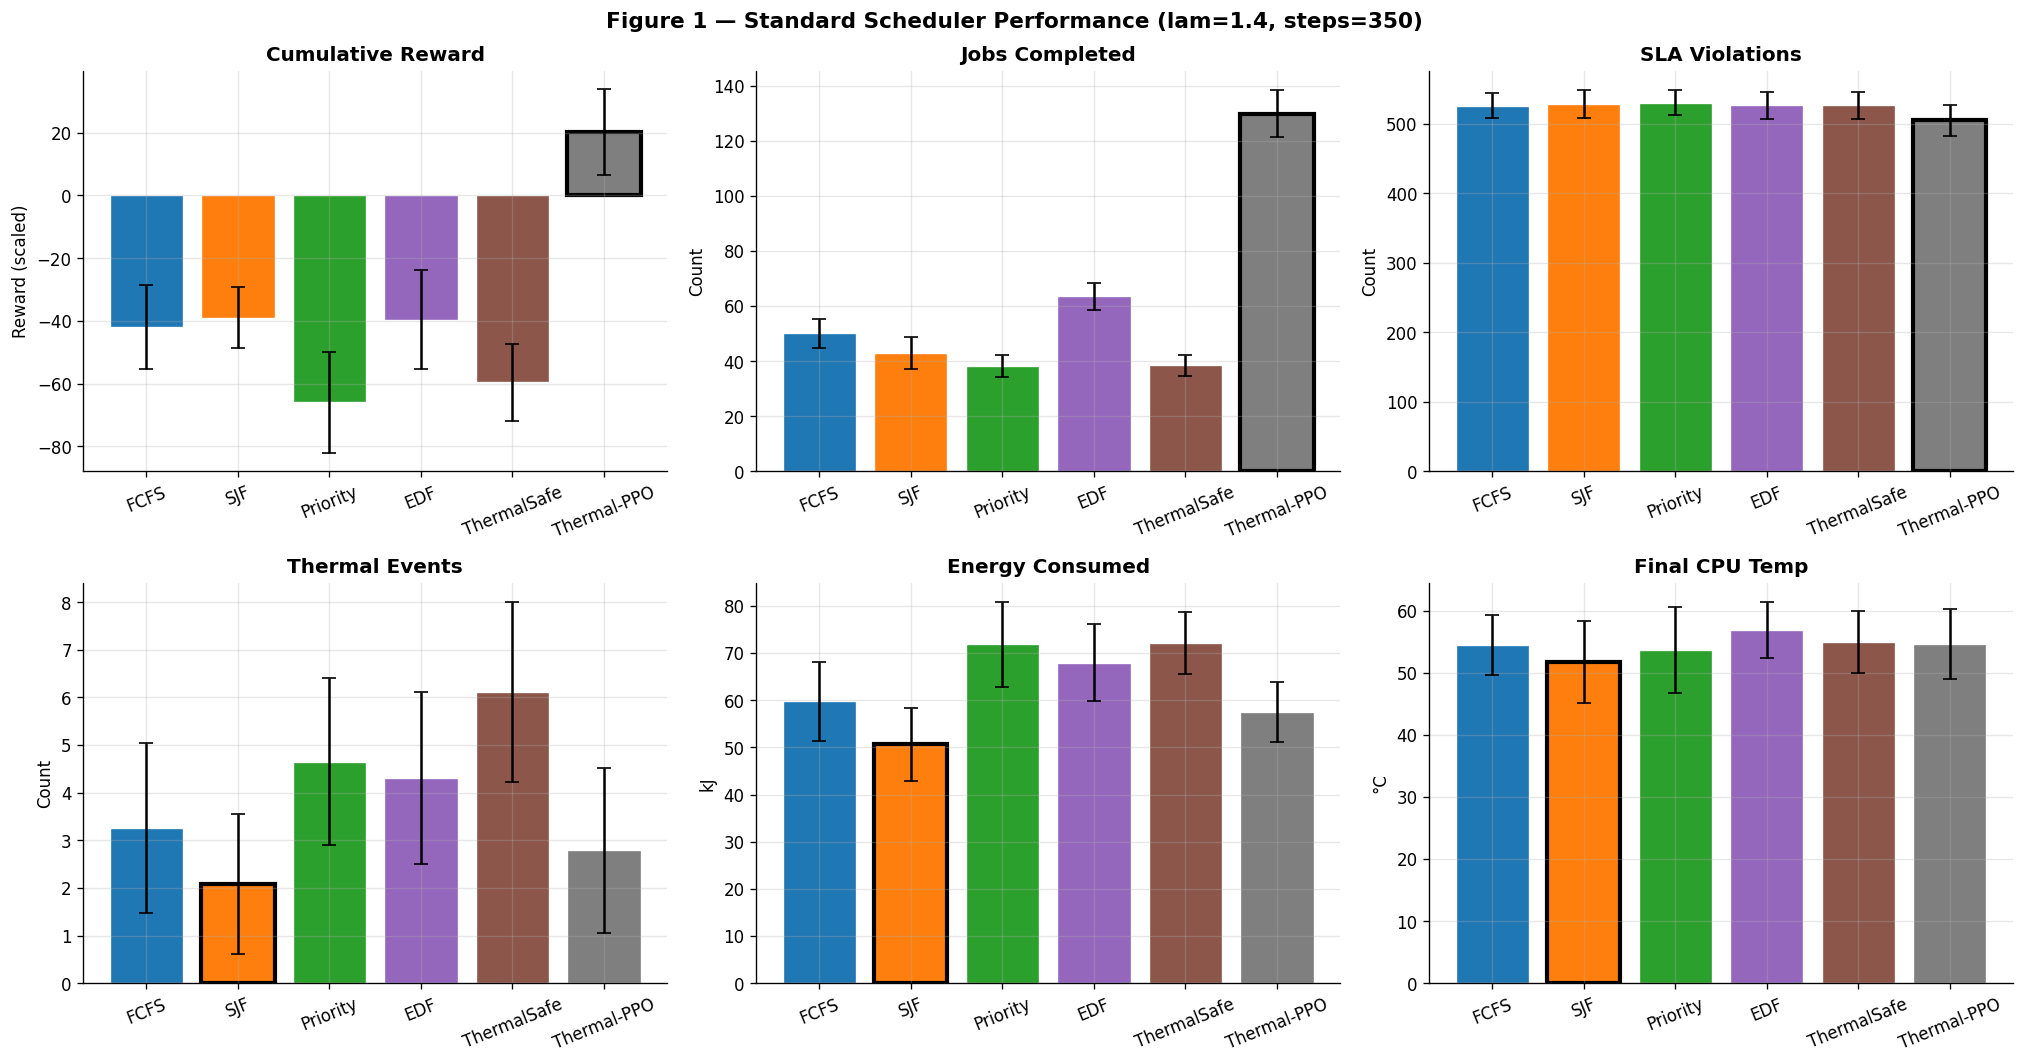

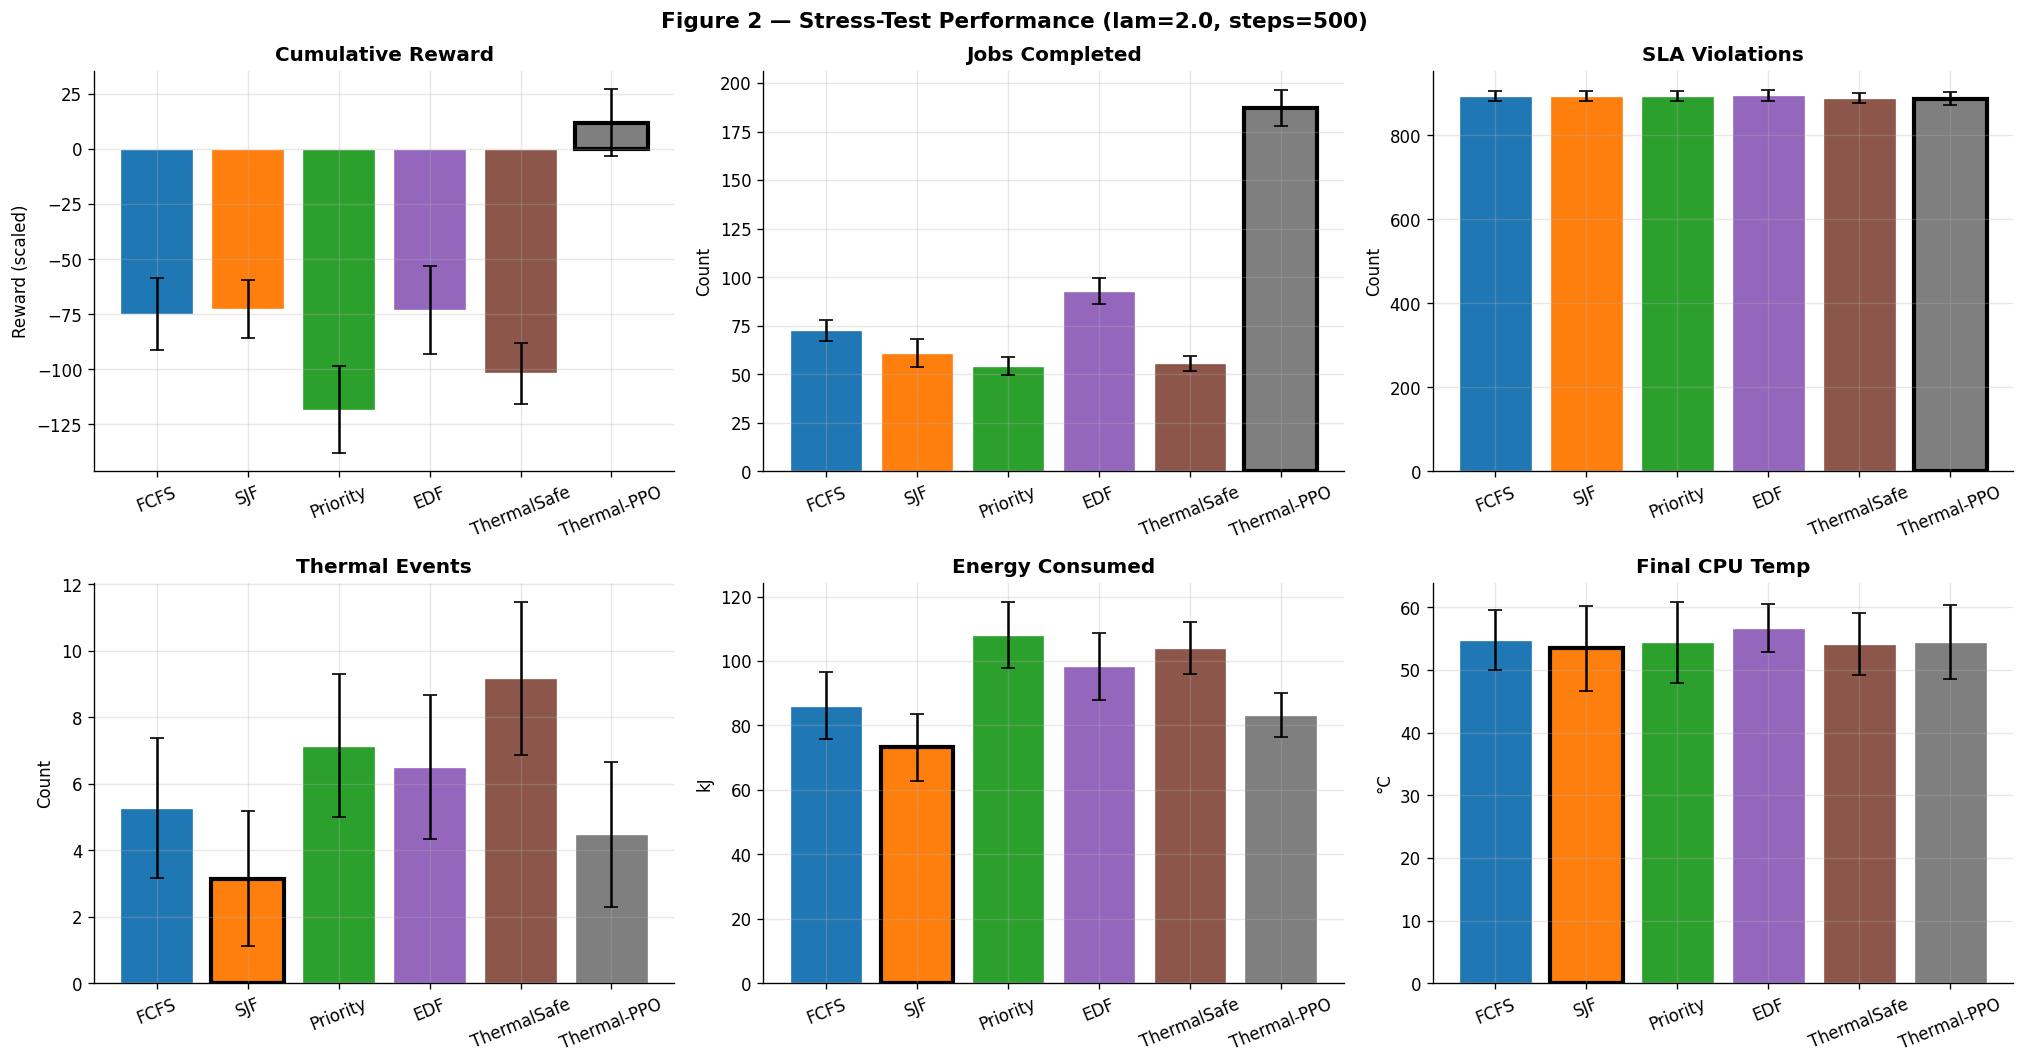

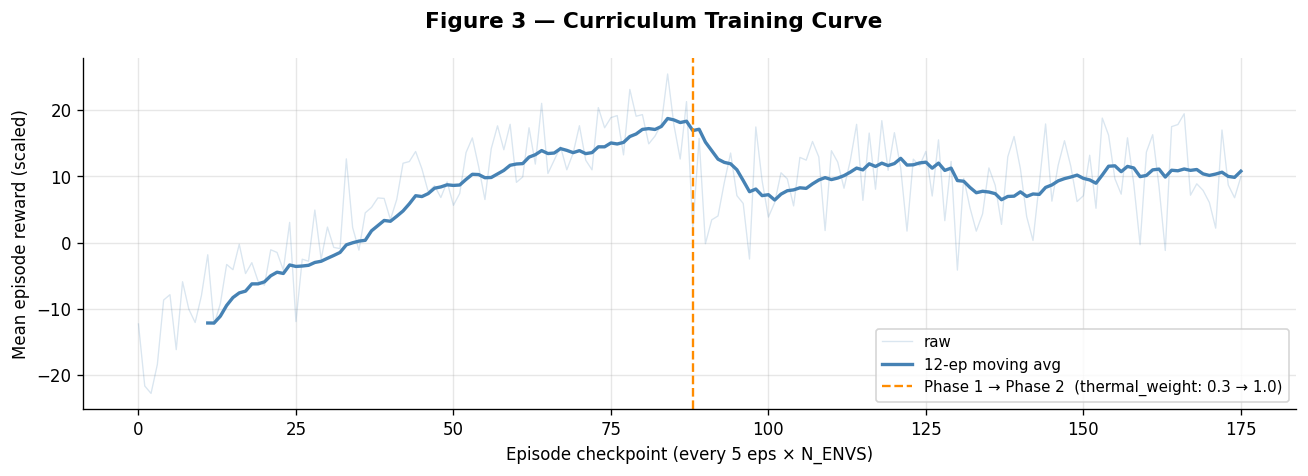

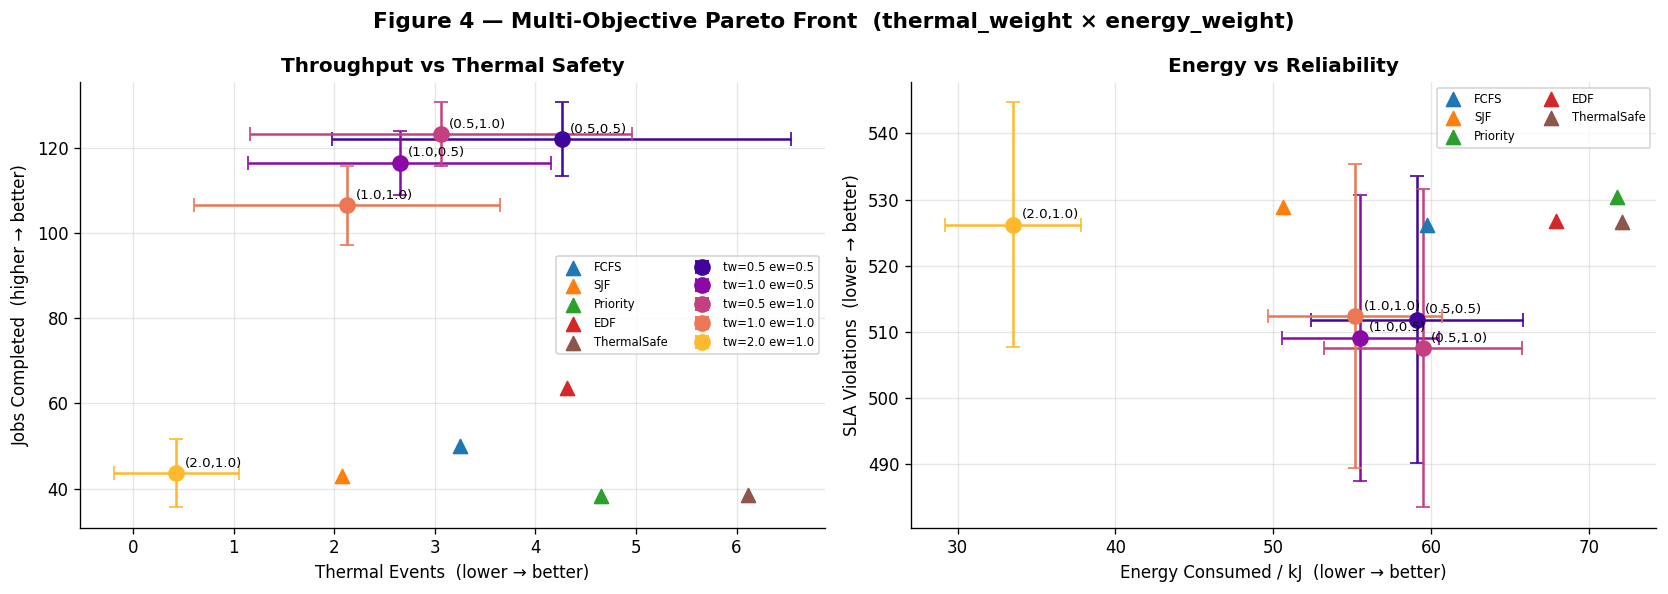

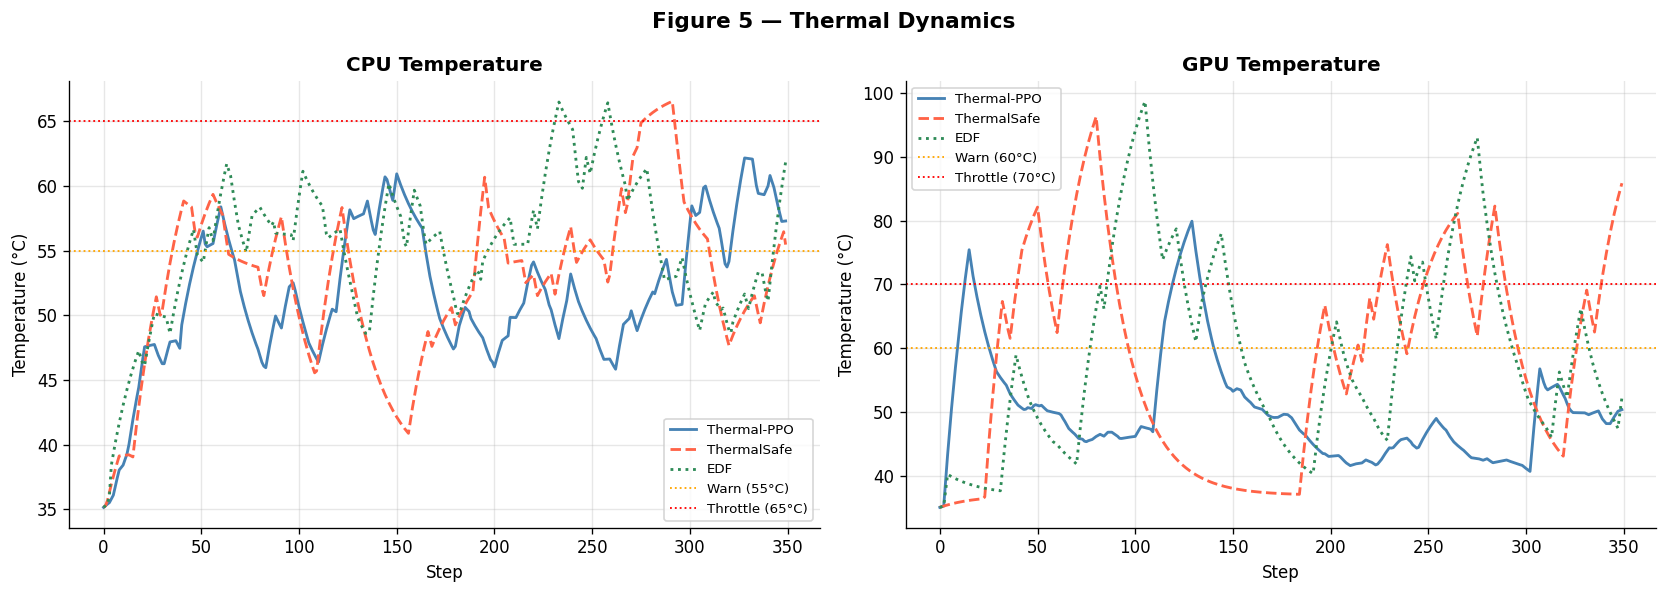


All done.


In [13]:
# =================================================================================================
# PLOTTING SETUP
# =================================================================================================

plt.rcParams.update({
    "figure.dpi":         120,
    "font.size":          10,
    "axes.grid":          True,
    "grid.alpha":         0.30,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

MAIN_NAMES = [s.name for s in BASELINES] + ["Thermal-PPO"]
PALETTE    = plt.cm.tab10(np.linspace(0, 0.7, len(MAIN_NAMES)))


def _bar(ax, data_dict, metric, title, ylabel, names=MAIN_NAMES, palette=PALETTE,
         lower_better=False):
    vals = [data_dict[n][metric][0] for n in names]
    errs = [data_dict[n][metric][1] for n in names]
    bars = ax.bar(names, vals, yerr=errs, capsize=4,
                  color=palette, edgecolor="white", linewidth=0.8)
    best = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best].set_edgecolor("black"); bars[best].set_linewidth(2.5)
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=22)

# =================================================================================================
# FIGURE 1 — Standard performance
# =================================================================================================

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Figure 1 — Standard Scheduler Performance (lam=1.4, steps=350)",
             fontweight="bold", fontsize=13)

_bar(axes[0,0], results, "reward",     "Cumulative Reward",  "Reward (scaled)")
_bar(axes[0,1], results, "completed",  "Jobs Completed",     "Count")
_bar(axes[0,2], results, "sla_viol",   "SLA Violations",     "Count",        lower_better=True)
_bar(axes[1,0], results, "thermal_ev", "Thermal Events",     "Count",        lower_better=True)
_bar(axes[1,1], results, "energy",     "Energy Consumed",    "kJ",           lower_better=True)
_bar(axes[1,2], results, "cpu_temp",   "Final CPU Temp",     "°C",           lower_better=True)

plt.tight_layout()
plt.savefig("fig1_standard_performance.png", bbox_inches="tight")
plt.show()

# =================================================================================================
# FIGURE 2 — Stress-test performance  [D]
# =================================================================================================

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Figure 2 — Stress-Test Performance (lam=2.0, steps=500)",
             fontweight="bold", fontsize=13)

_bar(axes[0,0], results_hard, "reward",     "Cumulative Reward",  "Reward (scaled)")
_bar(axes[0,1], results_hard, "completed",  "Jobs Completed",     "Count")
_bar(axes[0,2], results_hard, "sla_viol",   "SLA Violations",     "Count",        lower_better=True)
_bar(axes[1,0], results_hard, "thermal_ev", "Thermal Events",     "Count",        lower_better=True)
_bar(axes[1,1], results_hard, "energy",     "Energy Consumed",    "kJ",           lower_better=True)
_bar(axes[1,2], results_hard, "cpu_temp",   "Final CPU Temp",     "°C",           lower_better=True)

plt.tight_layout()
plt.savefig("fig2_stress_performance.png", bbox_inches="tight")
plt.show()

# =================================================================================================
# FIGURE 3 — Curriculum training curve  [B]
# =================================================================================================

if curve_main:
    fig, ax = plt.subplots(figsize=(11, 4))
    fig.suptitle("Figure 3 — Curriculum Training Curve",
                 fontweight="bold", fontsize=13)

    xs      = np.arange(len(curve_main))
    window  = 12
    smooth  = np.convolve(curve_main, np.ones(window)/window, mode="valid")

    ax.plot(xs, curve_main, alpha=0.20, color="steelblue", linewidth=0.8, label="raw")
    ax.plot(xs[window-1:], smooth, color="steelblue", linewidth=2.0,
            label=f"{window}-ep moving avg")

    if phase1_cut < len(xs):
        ax.axvline(phase1_cut, color="darkorange", linestyle="--", linewidth=1.4,
                   label="Phase 1 → Phase 2  (thermal_weight: 0.3 → 1.0)")

    ax.set_xlabel("Episode checkpoint (every 5 eps × N_ENVS)")
    ax.set_ylabel("Mean episode reward (scaled)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig("fig3_training_curve.png", bbox_inches="tight")
    plt.show()

# =================================================================================================
# FIGURE 4 — Pareto front  [C]
# =================================================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 4 — Multi-Objective Pareto Front  (thermal_weight × energy_weight)",
             fontweight="bold", fontsize=13)

pareto_palette = plt.cm.plasma(np.linspace(0.1, 0.85, len(PARETO_CONFIGS)))

# Left: jobs completed vs thermal events
ax = axes[0]
for (tw, ew), color in zip(PARETO_CONFIGS, pareto_palette):
    label  = f"tw={tw}_ew={ew}"
    r      = pareto_results[label]
    x, xe  = r["thermal_ev"]
    y, ye  = r["completed"]
    ax.errorbar(x, y, xerr=xe, yerr=ye, fmt="o", color=color,
                capsize=4, markersize=9, linewidth=1.5,
                label=f"tw={tw} ew={ew}")
    ax.annotate(f"({tw},{ew})", (x, y),
                textcoords="offset points", xytext=(5, 4), fontsize=8)

# also plot baselines for reference
for s, color in zip(BASELINES, plt.cm.tab10(np.linspace(0, 0.5, len(BASELINES)))):
    r     = results[s.name]
    ax.scatter(r["thermal_ev"][0], r["completed"][0],
               marker="^", s=70, color=color, label=s.name, zorder=3)

ax.set_xlabel("Thermal Events  (lower → better)")
ax.set_ylabel("Jobs Completed  (higher → better)")
ax.set_title("Throughput vs Thermal Safety", fontweight="bold")
ax.legend(fontsize=7, ncol=2)

# Right: energy vs SLA violations
ax = axes[1]
for (tw, ew), color in zip(PARETO_CONFIGS, pareto_palette):
    label  = f"tw={tw}_ew={ew}"
    r      = pareto_results[label]
    x, xe  = r["energy"]
    y, ye  = r["sla_viol"]
    ax.errorbar(x, y, xerr=xe, yerr=ye, fmt="o", color=color,
                capsize=4, markersize=9, linewidth=1.5)
    ax.annotate(f"({tw},{ew})", (x, y),
                textcoords="offset points", xytext=(5, 4), fontsize=8)

for s, color in zip(BASELINES, plt.cm.tab10(np.linspace(0, 0.5, len(BASELINES)))):
    r = results[s.name]
    ax.scatter(r["energy"][0], r["sla_viol"][0],
               marker="^", s=70, color=color, label=s.name, zorder=3)

ax.set_xlabel("Energy Consumed / kJ  (lower → better)")
ax.set_ylabel("SLA Violations  (lower → better)")
ax.set_title("Energy vs Reliability", fontweight="bold")
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("fig4_pareto_front.png", bbox_inches="tight")
plt.show()

# =================================================================================================
# FIGURE 5 — Thermal dynamics comparison
# =================================================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 5 — Thermal Dynamics",
             fontweight="bold", fontsize=13)

for label, policy_fn, color, ls in [
    ("Thermal-PPO",  rl_fn(model_main),                               "steelblue", "-"),
    ("ThermalSafe",  lambda obs, env: ThermalSafeScheduler().act(env), "tomato",    "--"),
    ("EDF",          lambda obs, env: EDFScheduler().act(env),         "seagreen",  ":"),
]:
    env = ThermalAwareSchedulingEnv()
    obs, _ = env.reset()
    cpu_ts, gpu_ts = [], []
    done = False
    while not done:
        a = policy_fn(obs, env)
        obs, _, done, _, _ = env.step(a)
        cpu_ts.append(env.cpu_temp)
        gpu_ts.append(env.gpu_temp)
    axes[0].plot(cpu_ts, label=label, color=color, linestyle=ls, linewidth=1.7)
    axes[1].plot(gpu_ts, label=label, color=color, linestyle=ls, linewidth=1.7)

_ref = ThermalAwareSchedulingEnv()
for ax, title, warn, limit in [
    (axes[0], "CPU Temperature", _ref.cpu_warn_temp, _ref.cpu_throttle_temp),
    (axes[1], "GPU Temperature", _ref.gpu_warn_temp, _ref.gpu_throttle_temp),
]:
    ax.axhline(warn,  color="orange", linestyle=":", linewidth=1.1, label=f"Warn ({warn:.0f}°C)")
    ax.axhline(limit, color="red",    linestyle=":", linewidth=1.1, label=f"Throttle ({limit:.0f}°C)")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Step"); ax.set_ylabel("Temperature (°C)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig5_thermal_dynamics.png", bbox_inches="tight")
plt.show()

print("\nAll done.")